In [104]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

RAW_PROCESSED_PATH = "../data/processed/"
df_monthly = pd.read_csv(RAW_PROCESSED_PATH + "sales_monthly_clean.csv")

df_monthly['datum'] = pd.to_datetime(df_monthly['datum'])
df_monthly.set_index('datum', inplace = True)

drug_cols = ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
df_monthly['total_sales'] = df_monthly[drug_cols].sum(axis=1)


In [105]:
#defining train and test

train = df_monthly[:'2018-12-31']
test = df_monthly['2019-01-01':]

print(f"Train shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"Train range: {train.index.min()} to {train.index.max()}")
print(f"Test range: {test.index.min()} to {test.index.max()}")

Train shape: (60, 11)
Test Shape: (10, 11)
Train range: 2014-01-31 00:00:00 to 2018-12-31 00:00:00
Test range: 2019-01-31 00:00:00 to 2019-10-31 00:00:00


In [106]:
df_monthly['lag_12'] = df_monthly['total_sales'].shift(12)

In [107]:
train = df_monthly[:'2018-12-31']
test = df_monthly['2019-01-01':]

In [108]:
naive_predictions = test['lag_12']
actual_values = test['total_sales']

print("Actual values:")
print(actual_values)

print("\nNaive predictions (lag_12):")
print(naive_predictions)

Actual values:
datum
2019-01-31    2907.863
2019-02-28    1944.197
2019-03-31    2038.938
2019-04-30    1756.805
2019-05-31    1822.160
2019-06-30    1482.407
2019-07-31    1517.941
2019-08-31    1377.779
2019-09-30    1864.387
2019-10-31     538.600
Name: total_sales, dtype: float64

Naive predictions (lag_12):
datum
2019-01-31    1985.701
2019-02-28    2203.248
2019-03-31    2156.847
2019-04-30    1934.480
2019-05-31    1675.130
2019-06-30    1414.349
2019-07-31    1563.479
2019-08-31    1611.907
2019-09-30    1981.374
2019-10-31    2221.335
Name: lag_12, dtype: float64


In [109]:
mae = mean_absolute_error(actual_values, naive_predictions)
rmse = np.sqrt(mean_squared_error(actual_values, naive_predictions))
print(f"Naive Model MAE: {mae:.2f}")
print(f"Naive Model RMSE: {rmse:.2f}")

Naive Model MAE: 377.13
Naive Model RMSE: 623.81


In [110]:
#ARIMA MODEL

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['total_sales'], order = (1,0,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            total_sales   No. Observations:                   60
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -448.607
Date:                Sat, 20 Jun 2026   AIC                            905.215
Time:                        14:04:14   BIC                            913.592
Sample:                    01-31-2014   HQIC                           908.491
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1823.3794    130.925     13.927      0.000    1566.772    2079.987
ar.L1          0.5709      0.425      1.344      0.179      -0.262       1.403
ma.L1         -0.2516      0.481     -0.523      0.6

C:\Users\tapas\OneDrive\Desktop\pharma-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\tapas\OneDrive\Desktop\pharma-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\tapas\OneDrive\Desktop\pharma-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [111]:
arima_forecast = model_fit.forecast(steps=10)
print(arima_forecast)

2019-01-31    1991.716675
2019-02-28    1919.483056
2019-03-31    1878.244929
2019-04-30    1854.702109
2019-05-31    1841.261528
2019-06-30    1833.588308
2019-07-31    1829.207673
2019-08-31    1826.706770
2019-09-30    1825.279007
2019-10-31    1824.463898
Freq: ME, Name: predicted_mean, dtype: float64


In [112]:
arima_mae = mean_absolute_error(test['total_sales'],arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['total_sales'],arima_forecast))

print(f"ARIMA MODEL MAE: {arima_mae:.2f}")
print(f"ARIMA MODEL RMSE: {arima_rmse:.2f}")

ARIMA MODEL MAE: 365.49
ARIMA MODEL RMSE: 543.36


In [113]:
#SARIMA MODEL

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train['total_sales'], order = (1,0,1), seasonal_order = (1,1,1,12))
sarima_fit = sarima_model.fit()
print(sarima_fit.summary())

C:\Users\tapas\OneDrive\Desktop\pharma-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\tapas\OneDrive\Desktop\pharma-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\tapas\OneDrive\Desktop\pharma-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


                                     SARIMAX Results                                      
Dep. Variable:                        total_sales   No. Observations:                   60
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -360.482
Date:                            Sat, 20 Jun 2026   AIC                            730.964
Time:                                    14:04:15   BIC                            740.320
Sample:                                01-31-2014   HQIC                           734.500
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9299      0.096      9.639      0.000       0.741       1.119
ma.L1         -0.6723      0.190   

In [114]:
sarima_forecast = sarima_fit.forecast(steps = 10)
print(sarima_forecast)

2019-01-31     888.767487
2019-02-28    1558.748886
2019-03-31    1692.497796
2019-04-30    1599.349012
2019-05-31    1510.312888
2019-06-30    1396.622315
2019-07-31    1364.636697
2019-08-31    1422.547430
2019-09-30    1769.380458
2019-10-31    2196.695825
Freq: ME, Name: predicted_mean, dtype: float64


In [115]:
sarima_mae = mean_absolute_error(test['total_sales'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['total_sales'], sarima_forecast))

print(f"SARIMA MODEL MAE: {sarima_mae:.2f}")
print(f"SARIMA MODEL RMSE: {sarima_rmse:.2f}")

SARIMA MODEL MAE: 525.72
SARIMA MODEL RMSE: 851.97


In [116]:
# 1. Create the missing lag features
df_monthly['lag_1'] = df_monthly['total_sales'].shift(1)
df_monthly['lag_2'] = df_monthly['total_sales'].shift(2)
df_monthly['lag_3'] = df_monthly['total_sales'].shift(3)

# 2. Create the rolling window features
df_monthly['rolling_mean_3'] = df_monthly['total_sales'].rolling(window=3).mean()
df_monthly['rolling_mean_6'] = df_monthly['total_sales'].rolling(window=6).mean()
df_monthly['rolling_std_3'] = df_monthly['total_sales'].rolling(window=3).std()

# 3. Create the cyclical calendar features (assuming your index is a DatetimeIndex)
df_monthly['month_sin'] = np.sin(2 * np.pi * df_monthly.index.month / 12)
df_monthly['month_cos'] = np.cos(2 * np.pi * df_monthly.index.month / 12)

In [117]:
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'month_sin','month_cos']
target_col = 'total_sales'

In [118]:
#dropping NAN values

df_model = df_monthly.dropna(subset = feature_cols + [target_col])
print(f"Original shape: {df_monthly.shape}")
print(f"After dropping NaN values: {df_model.shape}")

print(f"\nafter dropping NaN: \n{df_model}")

Original shape: (70, 20)
After dropping NaN values: (58, 20)

after dropping NaN: 
             m01ab    m01ae   n02ba     n02be   n05b  n05c     r03     r06  \
datum                                                                        
2015-01-31  135.91  130.349  141.00  1044.240  463.0  24.0  177.25   42.00   
2015-02-28  115.71  123.740  131.83   953.252  243.0   9.0  208.00   47.00   
2015-03-31  156.04  129.386  133.80  1084.850  208.0  13.0  195.00   54.00   
2015-04-30  154.50  101.115  122.10   940.170  192.0   5.0   97.00  112.00   
2015-05-31  160.02  119.117  136.04   765.900  194.0  10.0  100.00  159.50   
2015-06-30  151.87  113.690  145.46   746.788  217.0  12.0  193.00  125.80   
2015-07-31  175.61  113.810  125.50   708.828  203.0   6.0   60.00  130.30   
2015-08-31  181.69  144.519  133.40   790.788  265.5  15.0   45.00   83.70   
2015-09-30  166.22  134.122  110.40   852.125  243.5  11.0   91.00   71.00   
2015-10-31  195.81  127.231  146.20  1574.335  222.0   8.0 

In [119]:
X = df_model[feature_cols]
Y = df_model[target_col]

X_train = X[:'2018-12-31']
X_test = X['2019-01-01':]
Y_train = Y[:'2018-12-31']
Y_test = Y['2019-01-01':]

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (48, 9), X_test shape: (10, 9)


In [120]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
 
mae = mean_absolute_error(Y_test, Y_pred)
rmse = root_mean_squared_error(Y_test, Y_pred)

print("=" * 40)
print("       Model Evaluation Metrics       ")
print("=" * 40)
print(f"Mean Absolute Error (MAE)  : {mae:.4f}")
print(f"Root Mean Sq. Error (RMSE) : {rmse:.4f}")
print("=" * 40)

       Model Evaluation Metrics       
Mean Absolute Error (MAE)  : 298.4964
Root Mean Sq. Error (RMSE) : 396.8924


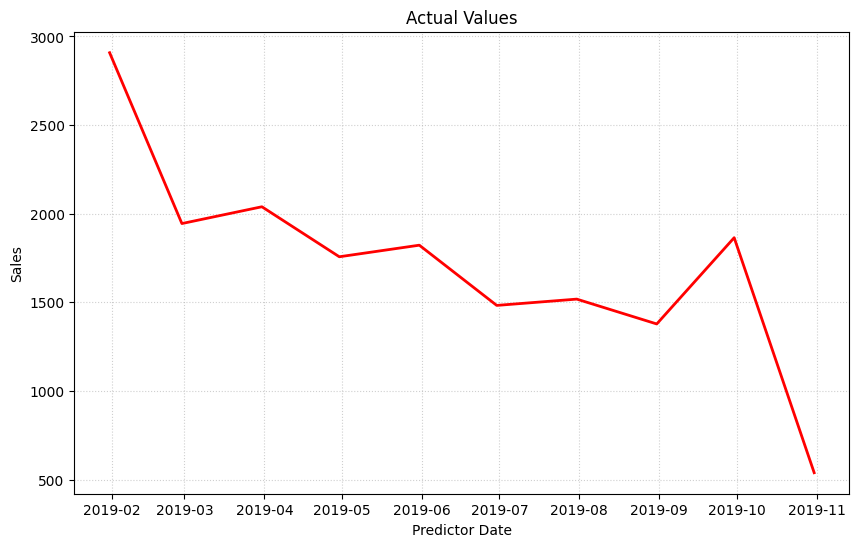

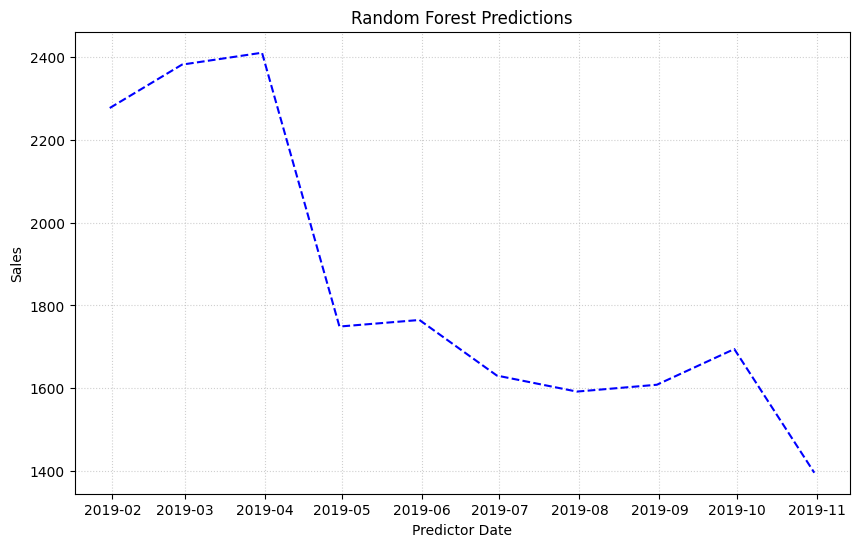

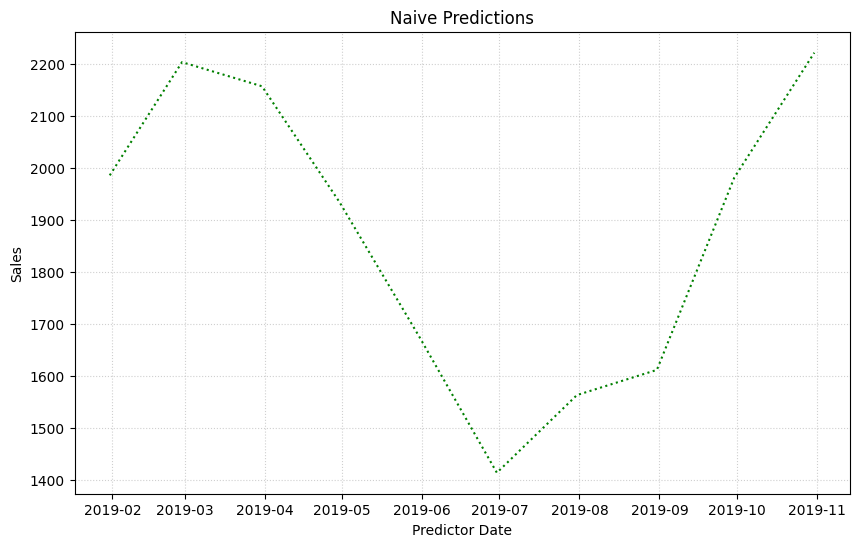

In [126]:
# 1. Plot Actual Values Separately
plt.figure(figsize=(10, 6))
plt.plot(actual_values.index, actual_values, color='Red', linewidth=2)
plt.title("Actual Values")
plt.xlabel("Predictor Date")
plt.ylabel("Sales")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 2. Plot Random Forest Predictions Separately
plt.figure(figsize=(10, 6))
plt.plot(Y_test.index, Y_pred, color='Blue', linestyle='--')
plt.title("Random Forest Predictions")
plt.xlabel("Predictor Date")
plt.ylabel("Sales")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 3. Plot Naive Predictions Separately
plt.figure(figsize=(10, 6))
plt.plot(naive_predictions.index, naive_predictions, color='Green', linestyle=':')
plt.title("Naive Predictions")
plt.xlabel("Predictor Date")
plt.ylabel("Sales")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

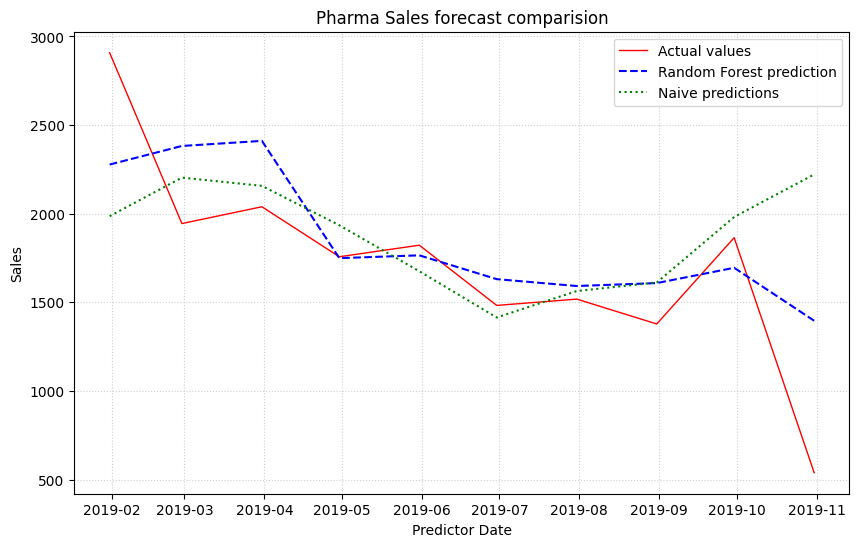

In [122]:
#plotting models

import matplotlib.pyplot as plt

plt.figure(figsize =(10,6))

plt.plot(actual_values.index, actual_values, label = "Actual values", color = "Red", linewidth=1)

plt.plot(Y_test.index, Y_pred, label = "Random Forest prediction", color = "Blue", linestyle = "--")

plt.plot(naive_predictions.index, naive_predictions, label = "Naive predictions", color = "Green", linestyle = ":")

plt.title("Pharma Sales forecast comparision")
plt.xlabel("Predictor Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [128]:
#MAPE

naive_MAPE = np.mean(np.abs(actual_values - naive_predictions) / actual_values) * 100

ARIMA_MAPE = np.mean(np.abs(actual_values - arima_forecast) / actual_values) * 100

SARIMA_MAPE = np.mean(np.abs(actual_values - sarima_forecast) / actual_values) * 100

RandomForest_MAPE = np.mean(np.abs(actual_values - Y_pred) / actual_values) * 100

print(f"Naive MAPE: {naive_MAPE}")
print(f"ARIMA MAPE: {ARIMA_MAPE}")
print(f"SARIMA MAPE: {SARIMA_MAPE}")
print(f"Random Forest MAPE: {RandomForest_MAPE}")

Naive MAPE: 41.22890031991987
ARIMA MAPE: 36.48977112155609
SARIMA MAPE: 46.44137114602492
Random Forest MAPE: 26.588668649750257


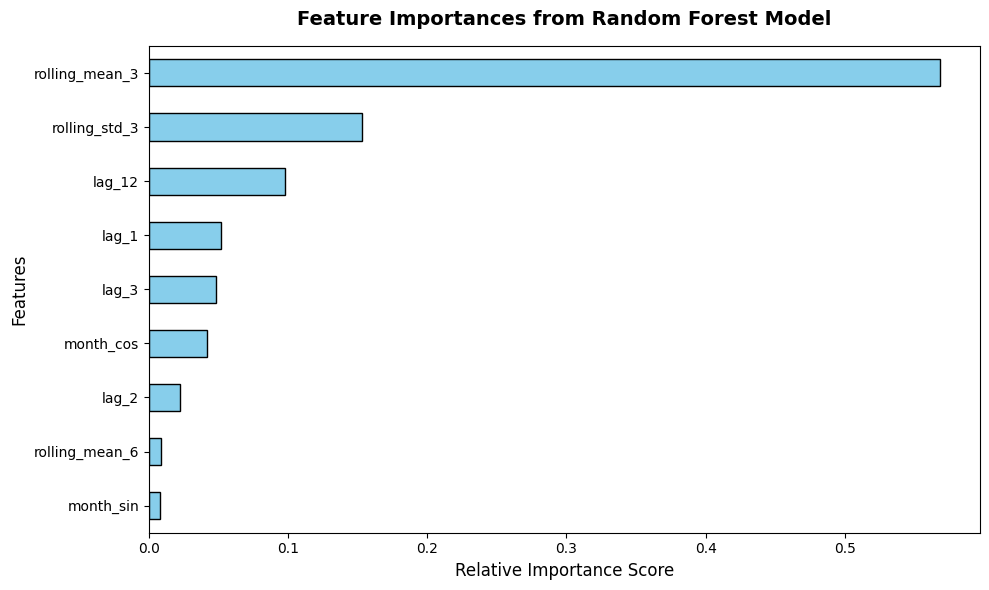

In [132]:
import pandas as pd

importances = model.feature_importances_

feat_importances = pd.Series(importances, index = X.columns)

feat_importances_sorted = feat_importances.sort_values(ascending = False)

fig, ax = plt.subplots(figsize=(10, 6))

feat_importances_sorted.plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')

ax.invert_yaxis()

ax.set_title('Feature Importances from Random Forest Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Relative Importance Score', fontsize=12)
ax.set_ylabel('Features', fontsize=12)

plt.tight_layout()